In [1]:
import sys
sys.path.append("../")

import numpy as np
np.random.seed(42)

from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.ar_model import AutoReg
from triple_env import TripleData, TripleMarket

data = TripleData("../../data/real_triple_XOM_CVX_COP.csv")
n  = len(data)
q1 = n // 4
q3 = n // 2   # intercept/std calibration from Q3 (closer to test period)
q4 = 3 * n // 4

# ── Johansen on Q1 ────────────────────────────────────────────────────────────
log_train = np.log(data.s[:, :q1]).T   # (q1, 3)
jres      = coint_johansen(log_train, det_order=0, k_ar_diff=1)

print("Trace statistic  |  r=0: {:.2f} (cv95={:.2f})  r<=1: {:.2f} (cv95={:.2f})".format(
    jres.lr1[0], jres.cvt[0,1], jres.lr1[1], jres.cvt[1,1]))

coint_vec = jres.evec[:, 0]   # first (strongest) cointegrating vector
print(f"Cointegrating vector  XOM={coint_vec[0]:.4f}  CVX={coint_vec[1]:.4f}  COP={coint_vec[2]:.4f}")

# ── Calibrate intercept + std from Q3 ─────────────────────────────────────────
def compute_spread(data, coint_vec, t_start, t_end):
    log_p = np.log(data.s[:, t_start:t_end])  # (3, T)
    return coint_vec @ log_p                   # (T,)

spread_q3 = compute_spread(data, coint_vec, q3, q4)
intercept = float(spread_q3.mean())
spread_q3 -= intercept
fixed_std  = float(spread_q3.std())
phi        = AutoReg(spread_q3, lags=1).fit().params[1]
wn_var     = fixed_std ** 2 * (1 - phi ** 2)

print(f"intercept={intercept:.4f} (Q3)  std={fixed_std:.4f}  phi={phi:.4f}")
print(f"Training: 0-{q4} ({q4} steps) | Test Q4: {q4}-{n} ({n-q4} steps)")

# ── Synthetic triple generation ────────────────────────────────────────────────
# ξ_t = v @ log(P_t) - intercept  →  AR(1)
# Two free random walks (log_s1, log_s2); derive log_s0 from the spread equation:
#   v[0]*log_s0 + v[1]*log_s1 + v[2]*log_s2 = ξ_t + intercept
#   => log_s0 = (ξ_t + intercept - v[1]*log_s1 - v[2]*log_s2) / v[0]
N, T = 50, q4
v = coint_vec

log_s1 = np.cumsum(np.c_[np.full(N, np.log(100.0)),
                          0.0005 + 0.015 * np.random.randn(N, T - 1)], axis=1)
log_s2 = np.cumsum(np.c_[np.full(N, np.log(100.0)),
                          0.0005 + 0.015 * np.random.randn(N, T - 1)], axis=1)

noise      = np.sqrt(wn_var) * np.random.randn(N, T)
spread_all = np.zeros((N, T))
for t in range(1, T):
    spread_all[:, t] = phi * spread_all[:, t - 1] + noise[:, t]

log_s0  = (spread_all + intercept - v[1] * log_s1 - v[2] * log_s2) / v[0]
triples = np.stack([np.exp(log_s0), np.exp(log_s1), np.exp(log_s2)], axis=1)  # (N, 3, T)

# Verify spread recovery
recovered = np.array([v @ np.log(triples[0, :, t]) - intercept for t in range(T)])
print(f"\nSynthetic spread recovery check (max error): {np.abs(recovered - spread_all[0]).max():.2e}")
print(f"Spread std target={fixed_std:.4f}  actual={spread_all.std(axis=1).mean():.4f}")

Trace statistic  |  r=0: 14.82 (cv95=29.80)  r<=1: 5.41 (cv95=15.49)
Cointegrating vector  XOM=9.6065  CVX=2.4661  COP=-4.1507
intercept=32.8564 (Q3)  std=1.8900  phi=0.9966
Training: 0-3772 (3772 steps) | Test Q4: 3772-5030 (1258 steps)

Synthetic spread recovery check (max error): 1.78e-14
Spread std target=1.8900  actual=1.6999


In [ ]:
%matplotlib widget

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN

EPISODE_LEN = 500  # length of each real-data training episode

class RealWindowTripleMarket(gym.Wrapper):
    """On each reset picks a random window from real Q1-Q3 data and recentres the spread."""
    def __init__(self, full_data, train_end, episode_len, coint_vec, **market_kwargs):
        self._full_data   = full_data
        self._train_end   = train_end
        self._episode_len = episode_len
        self._coint_vec   = np.asarray(coint_vec, dtype=np.float64)
        init_slice = full_data.slice(0, episode_len)
        env = TripleMarket(init_slice, coint_vec=coint_vec, **market_kwargs)
        super().__init__(env)

    def _make_slice(self, start):
        return self._full_data.slice(start, start + self._episode_len)

    def reset(self, **kwargs):
        max_start = self._train_end - self._episode_len
        start = np.random.randint(0, max_start)
        sliced = self._make_slice(start)
        # recentre spread for this window so it starts near zero
        log_p = np.log(sliced.s)
        local_intercept = float((self._coint_vec @ log_p).mean())
        self.env._data             = sliced
        self.env._spread_intercept = local_intercept
        return self.env.reset(**kwargs)


class FlatMarket(gym.Wrapper):
    """Flattens dict obs to 10-dim with RAW (signed) spread and z-score values."""
    def __init__(self, env):
        super().__init__(env)
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(10,), dtype=np.float32)

    def _flatten(self, obs):
        return np.array([
            float(obs["position"]),
            float(obs["spread_z_score"][0]),   # signed
            float(obs["entry_z_score"][0]),    # signed
            float(obs["spread"][0]),           # signed
            float(obs["entry_spread"][0]),     # signed
            float(obs["macd"][0]),
            float(obs["macd_signal"][0]),
            float(obs["macd_hist"][0]),
            float(obs["rolling_mean"][0]),     # signed
            float(obs["rolling_std"][0]),
        ], dtype=np.float32)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._flatten(obs), info

    def step(self, action):
        obs, reward, term, trunc, info = self.env.step(action)
        return self._flatten(obs), reward, term, trunc, info


env_kwargs = dict(
    coint_vec        = coint_vec,
    spread_intercept = intercept,
    fixed_std        = fixed_std,
    transaction_cost = 0.004,
)

train_env = FlatMarket(RealWindowTripleMarket(
    full_data   = data,
    train_end   = q4,
    episode_len = EPISODE_LEN,
    coint_vec   = coint_vec,
    fixed_std   = fixed_std,
    transaction_cost = 0.004,
))

TOTAL_STEPS = N * T
print(f"Training DQN on XOM/CVX/COP (real windows, raw obs) for {TOTAL_STEPS:,} steps...")

model = DQN("MlpPolicy", train_env, verbose=1,
            learning_rate=1e-4,
            buffer_size=100_000,
            learning_starts=2000,
            batch_size=64,
            gamma=0.999,
            exploration_fraction=0.6,
            exploration_final_eps=0.1,
            target_update_interval=500,
            train_freq=4)
model.learn(total_timesteps=TOTAL_STEPS)
print("Done.")

In [ ]:
import matplotlib.pyplot as plt
from static_thresh_base import ZScoreBaseline


class SB3Agent:
    def __init__(self, model):
        self.model = model

    def predict(self, obs):
        flat = np.array([
            float(obs["position"]),
            float(obs["spread_z_score"][0]),   # raw signed
            float(obs["entry_z_score"][0]),    # raw signed
            float(obs["spread"][0]),           # raw signed
            float(obs["entry_spread"][0]),     # raw signed
            float(obs["macd"][0]),
            float(obs["macd_signal"][0]),
            float(obs["macd_hist"][0]),
            float(obs["rolling_mean"][0]),
            float(obs["rolling_std"][0]),
        ], dtype=np.float32)
        action, _ = self.model.predict(flat, deterministic=True)
        return int(action)


def run_triple_strategy(env: TripleMarket, agent):
    obs, _ = env.reset()
    pnl, spreads, zscores, entries, exits = [], [], [], [], []
    step = 0
    while True:
        action        = agent.predict(obs)
        in_pos_before = obs["position"]
        spreads.append(float(obs["spread"][0]))
        zscores.append(float(obs["spread_z_score"][0]))
        obs, _, terminated, truncated, _ = env.step(action)
        pnl.append(env._get_pnl())
        if action == 1:
            (entries if in_pos_before == 0 else exits).append(step)
        step += 1
        if terminated or truncated:
            break
    return {"pnl": np.array(pnl), "spreads": np.array(spreads),
            "zscores": np.array(zscores), "entries": entries, "exits": exits}


def plot_triple_strategy(results, title=""):
    pnl     = results["pnl"]
    zscores = results["zscores"]
    entries = results["entries"]
    exits   = results["exits"]

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    initial   = float(pnl[~np.isnan(pnl)][0])
    benchmark = initial * (1 + 0.05 / 252) ** np.arange(len(pnl))

    axes[0].plot(pnl, label="strategy")
    axes[0].plot(benchmark, color="gray", linewidth=1, linestyle="--", label="5% p.a.")
    if entries: axes[0].scatter(entries, pnl[entries], color="green", s=10, zorder=5, label="entry")
    if exits:   axes[0].scatter(exits,   pnl[exits],   color="red",   s=10, zorder=5, label="exit")
    axes[0].set_title(f"Portfolio Value  {title}")
    axes[0].set_ylabel("Value ($)")
    axes[0].legend()

    axes[1].plot(zscores)
    axes[1].axhline(0,    color="gray",   linewidth=0.8, linestyle="--")
    axes[1].axhline( 2.0, color="green",  linewidth=0.8, linestyle="--", label="+2")
    axes[1].axhline(-2.0, color="green",  linewidth=0.8, linestyle="--", label="-2")
    axes[1].axhline( 0.5, color="orange", linewidth=0.8, linestyle="--")
    axes[1].axhline(-0.5, color="orange", linewidth=0.8, linestyle="--")
    if entries: axes[1].scatter(entries, zscores[entries], color="green", s=10, zorder=5)
    if exits:   axes[1].scatter(exits,   zscores[exits],   color="red",   s=10, zorder=5)
    axes[1].set_title("Z-scored spread")
    axes[1].set_ylabel("Z-score")
    axes[1].set_xlabel("Time step")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def metrics(results, label, rf_annual=0.05):
    pnl            = results["pnl"]
    n_days         = len(pnl)
    daily_returns  = np.diff(pnl) / pnl[:-1]
    excess_returns = daily_returns - rf_annual / 252
    sharpe         = excess_returns.mean() / (excess_returns.std() + 1e-12) * np.sqrt(252)
    running_max    = np.maximum.accumulate(pnl)
    max_drawdown   = ((pnl - running_max) / running_max).min()
    total_return   = (pnl[-1] - pnl[0]) / pnl[0]
    ann_return     = (1 + total_return) ** (252 / n_days) - 1
    print(f"{label}")
    print(f"  Sharpe ratio      : {sharpe:.3f}")
    print(f"  Max drawdown      : {max_drawdown*100:.2f}%")
    print(f"  Annualised return : {ann_return*100:.2f}%")
    print(f"  Trades            : {len(results['entries'])} entries, {len(results['exits'])} exits")
    print()


eval_kwargs = dict(coint_vec=coint_vec, spread_intercept=intercept, fixed_std=fixed_std)
q4_data = data.slice(q4)

results_dqn = run_triple_strategy(TripleMarket(q4_data, **eval_kwargs), SB3Agent(model))
print("--- DQN XOM/CVX/COP triple (real Q4) ---")
plot_triple_strategy(results_dqn, title="DQN | XOM/CVX/COP Q4")
metrics(results_dqn, "DQN — XOM/CVX/COP real Q4")

results_base = run_triple_strategy(
    TripleMarket(q4_data, **eval_kwargs),
    ZScoreBaseline(entry_threshold=2.0, exit_threshold=0.5)
)
print("--- Z-score baseline (real Q4) ---")
plot_triple_strategy(results_base, title="Z-score baseline | XOM/CVX/COP Q4")
metrics(results_base, "Z-score baseline — XOM/CVX/COP real Q4")

--- DQN on synthetic triple series 0 ---


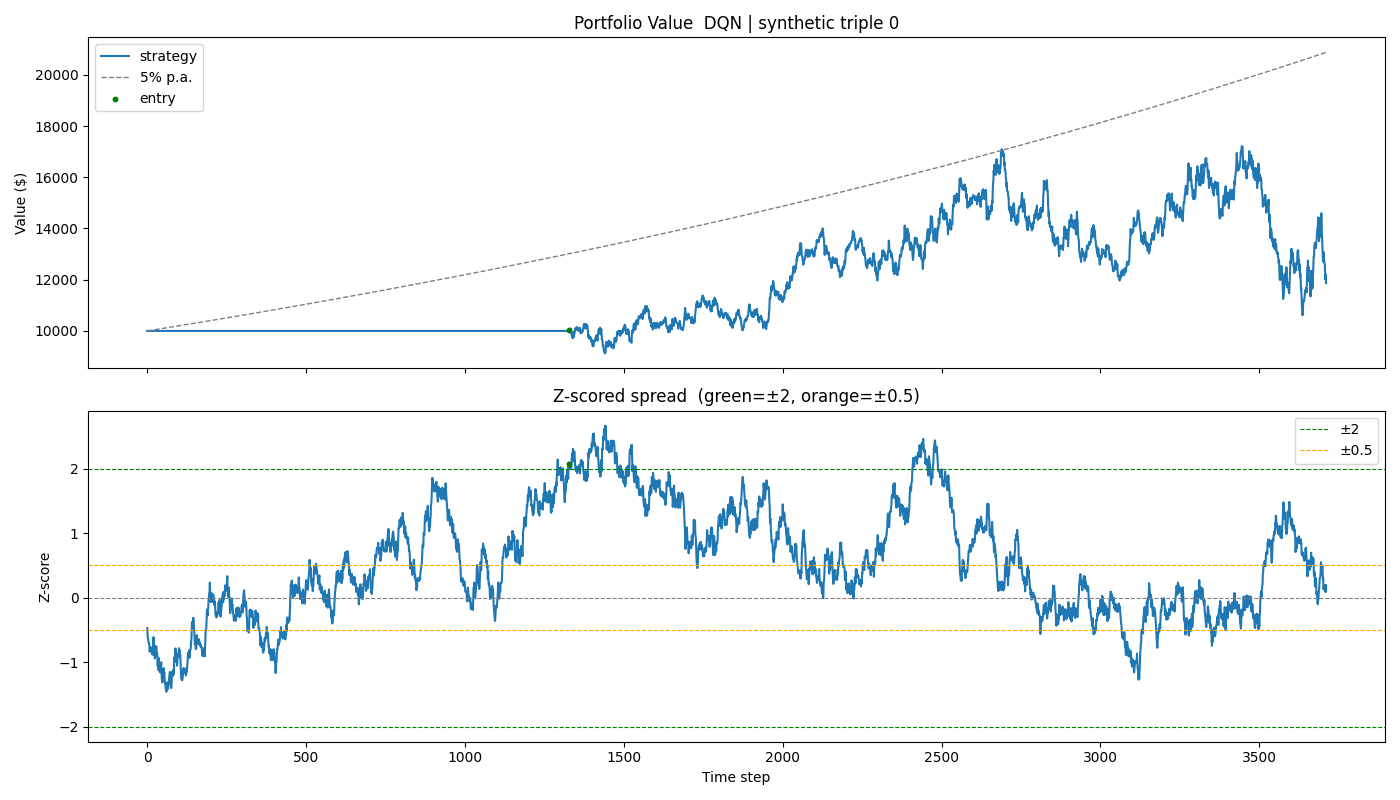

DQN — synthetic triple 0
  Sharpe ratio      : -0.175
  Max drawdown      : -38.35%
  Annualised return : 1.17%
  Trades            : 1 entries, 0 exits

--- Z-score baseline on synthetic triple ---


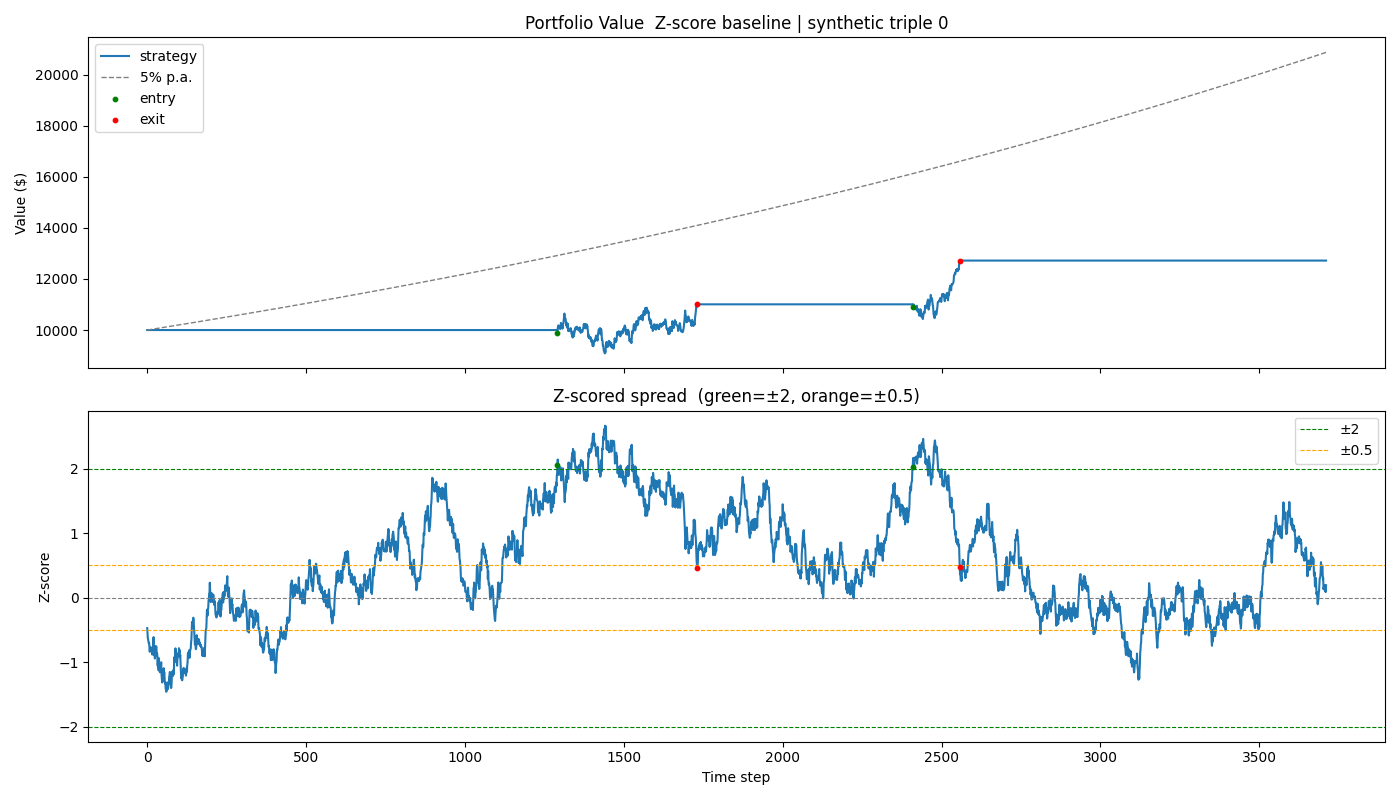

Z-score baseline — synthetic triple 0
  Sharpe ratio      : -0.549
  Max drawdown      : -14.65%
  Annualised return : 1.65%
  Trades            : 2 entries, 2 exits



In [4]:
# ── Evaluate on synthetic series 0 ────────────────────────────────────────────
synth_td            = object.__new__(TripleData)
synth_td.s          = triples[0]          # (3, T)
synth_td.labels     = ["XOM (synth)", "CVX (synth)", "COP (synth)"]
synth_td.timestamps = np.arange(T)

results_dqn_s = run_triple_strategy(TripleMarket(synth_td, **eval_kwargs), SB3Agent(model))
print("--- DQN on synthetic triple series 0 ---")
plot_triple_strategy(results_dqn_s, title="DQN | synthetic triple 0")
metrics(results_dqn_s, "DQN \u2014 synthetic triple 0")

results_base_s = run_triple_strategy(
    TripleMarket(synth_td, **eval_kwargs),
    ZScoreBaseline(entry_threshold=2.0, exit_threshold=0.5)
)
print("--- Z-score baseline on synthetic triple ---")
plot_triple_strategy(results_base_s, title="Z-score baseline | synthetic triple 0")
metrics(results_base_s, "Z-score baseline \u2014 synthetic triple 0")

--- DQN on unseen synthetic triple ---


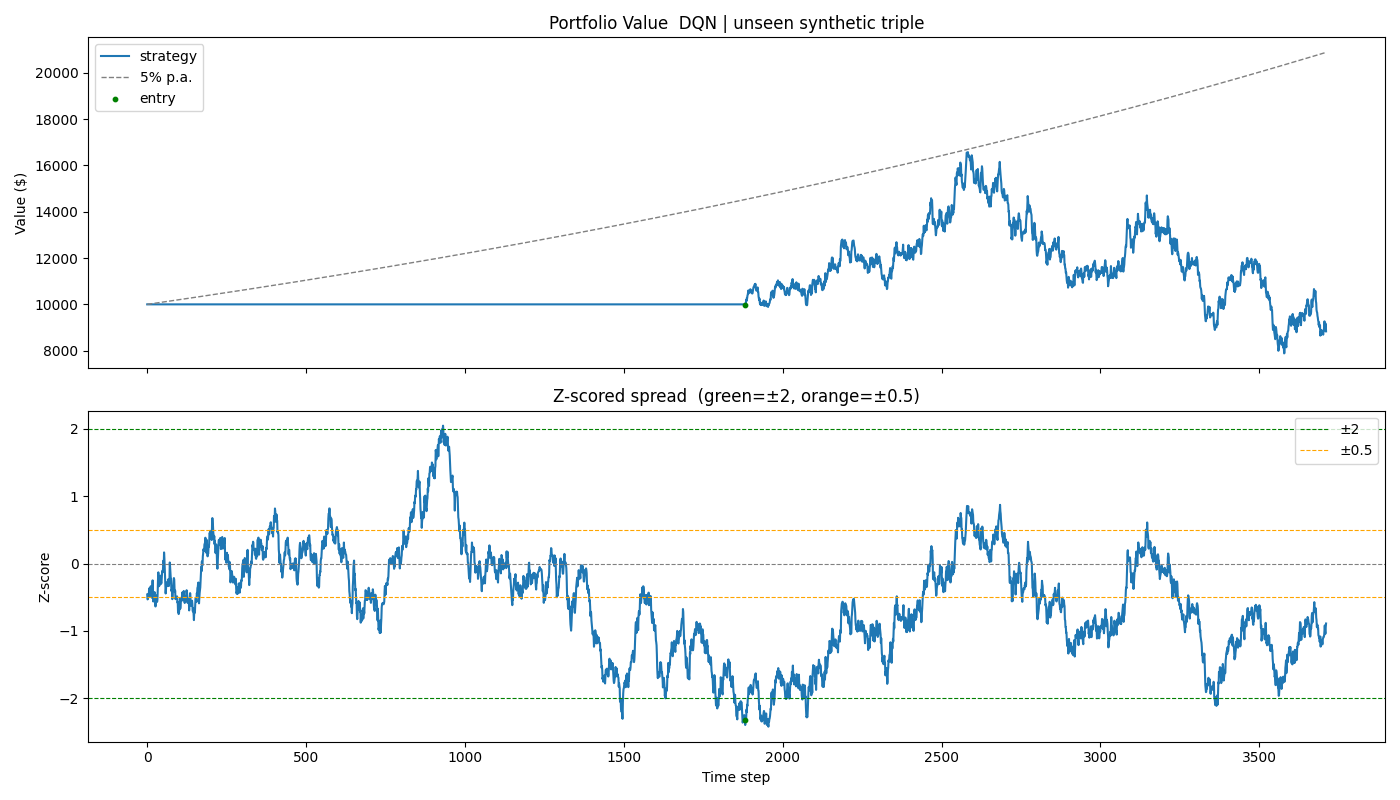

DQN — unseen synthetic triple
  Sharpe ratio      : -0.288
  Max drawdown      : -52.42%
  Annualised return : -0.84%
  Trades            : 1 entries, 0 exits



In [5]:
# ── Unseen synthetic triple (seed 999) ────────────────────────────────────────
rng = np.random.default_rng(999)
ls1_u = np.cumsum(np.c_[np.full(1, np.log(100.0)),
            0.0005 + 0.015 * rng.standard_normal((1, T - 1))], axis=1)
ls2_u = np.cumsum(np.c_[np.full(1, np.log(100.0)),
            0.0005 + 0.015 * rng.standard_normal((1, T - 1))], axis=1)
noise_u  = np.sqrt(wn_var) * rng.standard_normal((1, T))
spr_u    = np.zeros((1, T))
for t in range(1, T):
    spr_u[:, t] = phi * spr_u[:, t - 1] + noise_u[:, t]
ls0_u    = (spr_u + intercept - v[1] * ls1_u - v[2] * ls2_u) / v[0]
triple_u = np.stack([np.exp(ls0_u), np.exp(ls1_u), np.exp(ls2_u)], axis=1)  # (1,3,T)

unseen_td            = object.__new__(TripleData)
unseen_td.s          = triple_u[0]
unseen_td.labels     = ["XOM (unseen)", "CVX (unseen)", "COP (unseen)"]
unseen_td.timestamps = np.arange(T)

results_dqn_u = run_triple_strategy(TripleMarket(unseen_td, **eval_kwargs), SB3Agent(model))
print("--- DQN on unseen synthetic triple ---")
plot_triple_strategy(results_dqn_u, title="DQN | unseen synthetic triple")
metrics(results_dqn_u, "DQN \u2014 unseen synthetic triple")